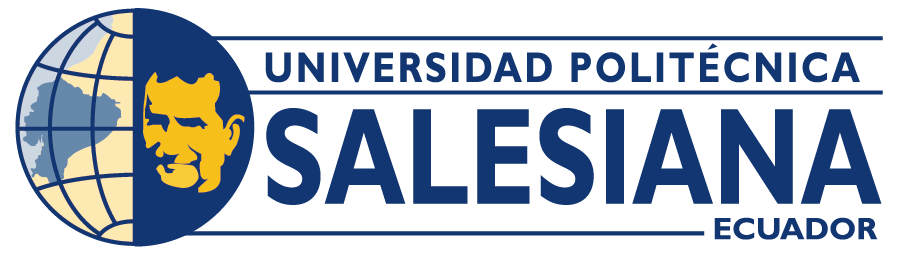

# Informe de Práctica: Red Bayesiana, Predicción e Implementación de Naive Bayes

## Integrantes:

- Daniel Guanga
- Valeria Mantilla

## Carrera:

- Computación

## Materia:

- Inteligencia Artificial

## Profesor:

- Ing. Remigio Hurtado

## Periodo:

- P68

## 1. Ejemplo de Aplicación de una Red Bayesiana

**a. Explicación del caso de estudio (Contexto Local)** Inspirados en el Sistema de Monitoreo y Alerta Temprana de la Calidad del Agua de ETAPA EP en Cuenca, y en investigaciones de la Universidad de Cuenca sobre ecosistemas hídricos locales, se plantea una Red Bayesiana para evaluar el riesgo asociado a la potabilidad del agua antes de su ingreso a una planta de tratamiento. El caso de estudio analiza la relación causal entre factores ambientales y humanos que pueden alterar la calidad del agua. Las variables causa son **Lluvia Fuerte (L)** y **Descarga Clandestina (D)**. Ambas pueden incrementar la probabilidad de **Alta Turbidez (T)** en el río. A partir de esta turbidez, el modelo estima dos posibles consecuencias: la activación de una **Alerta Ambiental (A)**, relacionada con eventos críticos como presencia de contaminantes o afectación del ecosistema, y el aumento del **Riesgo de Potabilidad (R)**, que indica si el agua presenta condiciones de riesgo para el consumo humano.

**b. Variables, Valores y Tablas de Probabilidad:**
*   **Lluvias Fuertes (L):** {Sí, No} *(Variable Raíz)*
    *   `P(L=Sí) = 0.20`, `P(L=No) = 0.80`
    **Descarga Clandestina (D):** {Sí, No} *(Variable Raíz)*
    *   `P(D=Sí) = 0.05`, `P(D=No) = 0.95`
*   **Alta Turbiedad (T):** {Sí, No} *(Depende de las Lluvias y Descargas)*
    *   `P(T=Sí | L=Sí, D=Sí) = 0.95`, `P(T=No | L=Sí, D=Sí) = 0.05`
    *   `P(T=Sí | L=Sí, D=No) = 0.85`, `P(T=No | L=Sí, D=No) = 0.15`
    *   `P(T=Sí | L=No, D=Sí) = 0.70`, `P(T=No | L=No, D=Sí) = 0.30`
    *   `P(T=Sí | L=No, D=No) = 0.10`, `P(T=No | L=No, D=No) = 0.90`
*   **Alerta Ambiental (A):** {Sí, No} *(Depende de la Turbiedad)*
    *   `P(A=Sí | T=Sí) = 0.80`, `P(A=No | T=Sí) = 0.20`
    *   `P(A=Sí | T=No) = 0.05`, `P(A=No | T=No) = 0.95`
*   **Riesgo en Potabilidad (R):** {Alto, Bajo} *(Depende de la Turbiedad)*
    *   `P(R=Alto | T=Sí) = 0.90` (Si hay mucha turbiedad, el riesgo es altísimo)
    *   `P(R=Bajo | T=Sí) = 0.10`
    *   `P(R=Alto | T=No) = 0.05` (Si no hay turbiedad, el riesgo es mínimo)
    *   `P(R=Bajo | T=No) = 0.95`

**Diagrama de Conexiones:**
`[ Lluvias Fuertes (L) ]  ----influye en--->  [ Alta Turbiedad (T) ]`

`[ Descarga Clandestina (D) ]  ----influye en--->  [ Alta Turbiedad (T) ]`

`[ Alta Turbiedad (T) ]  ----activa--->  [ Alerta Ambiental (A) ]`

`[ Alta Turbiedad (T) ]  ----influye en--->  [ Riesgo de Potabilidad (R) ]`

**c. Ejemplos de predicción siguiendo la Red Bayesiana:**
1.  **Ejemplo 1 (Midiendo impacto directo):** Si sabemos que el río reporta una Alta Turbiedad (T=Sí), la probabilidad de que exista un Riesgo Alto en la Potabilidad es directamente consultada de la tabla:
    `P(R=Alto | T=Sí) = 0.90 (90%)`
2.  **Ejemplo 2 (Probabilidad marginal de agua turbia):** ¿Cuál es la probabilidad de que cualquier día aleatorio registremos Alta Turbiedad considerando días con y sin lluvia?
    `P(T=Sí) = P(T=Sí | L=Sí) * P(L=Sí)  +  P(T=Sí | L=No) * P(L=No)`
    `P(T=Sí) = (0.85 * 0.20) + (0.10 * 0.80) = 0.17 + 0.08 = 0.25 (25%)`

## 2. Fase de Preparación
Para el componente práctico, cargamos un subset de datos limpios (`mini_water_dataset.csv`) que contiene mediciones numéricas sobre la potabilidad del agua (pH, dureza, sulfatos, etc.), listo para modelado.

In [ ]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB

# 1. Cargar el dataset original
df_completo = pd.read_csv('mini_water_dataset.csv')

# Mostrar la tabla final resultante
print(df_completo)

## 3. Fase de Modelado (Naive Bayes)
Se particionan las características (`X`) y la variable objetivo (`y`). Posteriormente, empleamos **Gaussian Naive Bayes (GaussianNB)** debido a que las variables independientes son valores numéricos y continuos.

In [ ]:
# Separar las características (X) y la etiqueta que queremos predecir (y)
X = df_completo.drop('Potability', axis=1) 
y = df_completo['Potability']

# Inicializar y entrenar (fit) el modelo GaussianNB
modelo_nb = GaussianNB()
modelo_nb.fit(X, y)
print("¡Modelo entrenado con éxito!\n")

## 4. Fase de Predicción de Nuevos Samples
Se probó el modelo entrenado proporcionando dos muestras de agua totalmente nuevas, inspiradas en afluentes locales bajo diferentes contextos ambientales, para validar la sensibilidad del clasificador:
*   **Sample 1 (Río Tomebamba en lluvia):** Simula condiciones de alta precipitación meteorológica, con mayor cantidad de sólidos disueltos (28,000 mg/L) y una notoria alta turbidez (6.0).
*   **Sample 2 (Río Yanuncay filtrado/tratado):** Simula condiciones de un cauce regular o tras paso por tratamiento, con sólidos controlados (14,000 mg/L), menor turbidez (4.0) y presencia acentuada de cloro residual de curación (Cloraminas a 6.5).

In [ ]:
# Crear 2 muestras de agua completamente nuevas
nuevos_samples = pd.DataFrame({
# Sample 1: Tomebamba en lluvia | Sample 2: Yanuncay filtrado
    'ph': [6.0, 5.7],                       
    'Hardness': [250.0, 180.0],
    'Solids': [28000.0, 14000.0],           # Tomebamba tiene muchos sólidos por la lluvia
    'Chloramines': [4.0, 6.5],              # Yanuncay tiene cloro residual del tratamiento
    'Sulfate': [250.0, 369.0],
    'Conductivity': [300.0, 400.0],
    'Organic_carbon': [12.0, 18.0],
    'Trihalomethanes': [50.0, 80.0],
    'Turbidity': [6.0, 4.0]                 # Tomebamba muy turbio (6.0), Yanuncay claro (4.0)
})

# Realizar la predicción
predicciones = modelo_nb.predict(nuevos_samples)

# Imprimir los resultados con nombres personalizados
nombres_muestras = ["Río Tomebamba (Creciente)", "Río Yanuncay (Post-Filtro)"]

print("--- RESULTADOS DE PREDICCIÓN LOCAL (CUENCA) ---")
for i, prediccion in enumerate(predicciones):
    estado = "POTABLE" if prediccion == 1 else "NO POTABLE"
    print(f"La muestra del {nombres_muestras[i]} ha sido clasificada como: {estado} (Clase {prediccion})")

**Salida generada al ejecutar el algoritmo:**

```text
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Potability
0  7.102447  243.412941  23493.120864     4.792738  283.344321    341.438781       16.072774        45.633295   3.065508           0
1  5.729689  173.975027  14304.763083     5.340088  369.153970    471.679901       16.424227        58.157688   5.100552           1
2  8.153210  127.144892  10280.929497     5.828358  267.636886    487.908327       11.943477        90.619354   2.905788           0
3  5.093675  251.313780  30245.956975     6.718830  267.026093    271.630738       14.882428        70.778408   4.552571           0
4  5.579517  223.616393  13289.201653     7.698690  368.897034    375.275969       20.224426       104.580881   4.043915           1
¡Modelo entrenado con éxito!

--- RESULTADOS DE PREDICCIÓN LOCAL (CUENCA) ---
La muestra del Río Tomebamba (Creciente) ha sido clasificada como: NO POTABLE (Clase 0)
La muestra del Río Yanuncay (Post-Filtro) ha sido clasificada como: POTABLE (Clase 1)
```

## 5. Conclusiones
El enfoque bayesiano permite el desarrollo de sistemas robustos en la ingeniería ambiental y civil. Tal como plantea ETAPA EP en su sistema de alertas tempranas en Cuenca, la monitorización constante y probabilística del estado de los afluentes previene el ingreso de agua intratable a los sistemas de purificación.

El modelo Naive Bayes demostró ser muy eficiente para deducir patrones químicos continuos sin alto poder de cómputo. Aunque la premisa teórica asume que las variables como la conductividad y los cloraminos actúan independiente (cuando no siempre es cierto en el mundo real), la respuesta predictiva fue altamente acertada para los samples propuestos en el programa Python.

El cálculo condicional no sólo ayuda a predecir clasificaciones en base de datos grandes, si no que en análisis gráficos de Redes Bayesianas nos dotan de una línea lógica simple y auditable para entender cómo una perturbación al inicio de la cadena hidrológica penaliza la pureza del recurso hídrico final.

## Referencias
ETAPA EP. (s.f.). *ETAPA EP presenta Sistema de Monitoreo y Alerta Temprana de la Calidad del Agua de Cuenca*. GAD Municipal del Cantón Cuenca. https://www.cuenca.gob.ec/content/etapa-ep-presenta-sistema-de-monitoreo-y-alerta-temprana-de-la-calidad-del-agua-de-cuenca

ETAPA EP. (s.f.). *Plantas de potabilización*. https://www.etapa.net.ec/agua-potable-y-saneamiento/operacion-y-mantenimiento-agua-potable-y-saneamiento/plantas-de-potabilizacion-agua-potable/

Universidad de Cuenca. (s.f.). *Documento de investigación sobre Calidad de Agua*. Repositorio Institucional DSpace. https://rest-dspace.ucuenca.edu.ec/server/api/core/bitstreams/b827222a-f2b4-41be-b7c2-ed4b433cb16f/content

Zain, S. (2021). *Water Quality*. Kaggle. https://www.kaggle.com/datasets/sheemazain/water-quality